In [11]:
import pandas as pd

df = pd.read_csv("Digital Payment Fraud Detection.csv")

df.head()
print(df.shape)
df.info()
print(df['fraud_label'].value_counts())

(7500, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 1

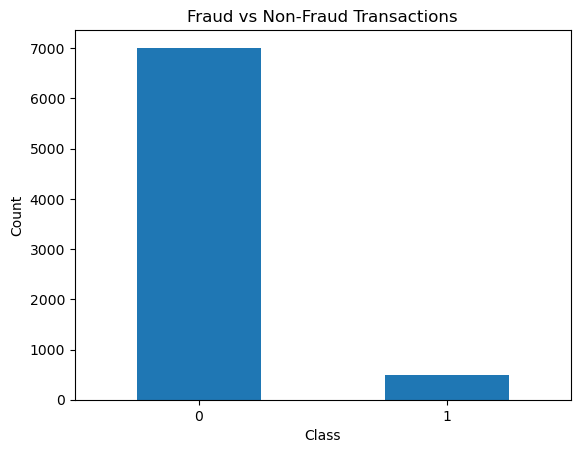

In [19]:
import matplotlib.pyplot as plt

df['fraud_label'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [21]:
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [23]:
df = df.drop(['transaction_id', 'user_id'], axis=1)# drop unwanted feature

In [27]:
#To convert a string column into a numerical column
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

categorical_columns = [
    'transaction_type',
    'payment_mode',
    'device_type',
    'device_location'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_amount        7500 non-null   float64
 1   transaction_type          7500 non-null   int64  
 2   payment_mode              7500 non-null   int64  
 3   device_type               7500 non-null   int64  
 4   device_location           7500 non-null   int64  
 5   account_age_days          7500 non-null   int64  
 6   transaction_hour          7500 non-null   int64  
 7   previous_failed_attempts  7500 non-null   int64  
 8   avg_transaction_amount    7500 non-null   float64
 9   is_international          7500 non-null   int64  
 10  ip_risk_score             7500 non-null   float64
 11  login_attempts_last_24h   7500 non-null   int64  
 12  fraud_label               7500 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 761.8 KB


In [31]:
# Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()
scaled_df.describe()

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,0.495901,0.499200,0.496267,0.500467,0.501267,0.501209,0.497212,0.503400,0.502694,0.100667,0.505026,0.499383,0.065200
std,0.289069,0.408683,0.373240,0.406762,0.353693,0.289408,0.302213,0.355395,0.287632,0.300907,0.289647,0.324235,0.246895
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.244761,0.000000,0.000000,0.000000,0.250000,0.247738,0.217391,0.250000,0.255024,0.000000,0.257000,0.250000,0.000000
50%,0.493938,0.500000,0.333333,0.500000,0.500000,0.506787,0.478261,0.500000,0.500879,0.000000,0.502000,0.500000,0.000000
75%,0.745721,1.000000,0.666667,1.000000,0.750000,0.751634,0.782609,0.750000,0.751728,0.000000,0.759000,0.750000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [1]:
# Selecting only fraud transactions for GAN training
fraud_data = scaled_df[scaled_df['fraud_label'] == 1]

# Remove label column
fraud_features = fraud_data.drop('fraud_label', axis=1)

print(fraud_features.shape)

NameError: name 'scaled_df' is not defined

In [39]:
# Fraud data is ready for training
print(type(fraud_data))
print(fraud_data.shape)

<class 'numpy.ndarray'>
(489, 13)


In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [43]:
# Building the Generator model
generator = Sequential([
    Dense(16, activation='relu', input_dim=100),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(13, activation='sigmoid')
])

generator.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │           1,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 13)                  │             845 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,117 (19.99 KB)

 Trainable params: 5,117 (19.99 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Building the Discriminator model
# The discriminator distinguishes between
# real and fake fraud transactions
discriminator = Sequential([
    Dense(64, activation='relu', input_dim=13),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

discriminator.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002),
    metrics=['accuracy']
)

discriminator.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Combining the Generator and Discriminator
# into a complete GAN model
discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002)
)

In [52]:
# Setting the training parameters
import numpy as np

epochs = 1000
batch_size = 32
noise_dim = 100

In [54]:
# Training the GAN model
# The generator creates fake fraud transactions
# while the discriminator learns to detect them
for epoch in range(epochs):

    # Select real fraud transactions
    idx = np.random.randint(0, fraud_data.shape[0], batch_size)
    real_data = fraud_data[idx]

    # Generate fake transactions
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_data = generator.predict(noise, verbose=0)

    # Labels
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

    # Train generator
    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_y = np.ones((batch_size, 1))

    g_loss = gan.train_on_batch(noise, valid_y)

    # Print progress
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]} | G Loss: {g_loss}")

C:\Users\user\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.7487110495567322 | G Loss: 0.7270327210426331
Epoch 100 | D Loss: 0.7221423983573914 | G Loss: 0.7000676393508911
Epoch 200 | D Loss: 0.7393710613250732 | G Loss: 0.6675708293914795
Epoch 300 | D Loss: 0.7545691132545471 | G Loss: 0.6401414275169373
Epoch 400 | D Loss: 0.7643520832061768 | G Loss: 0.6231768727302551
Epoch 500 | D Loss: 0.7704971432685852 | G Loss: 0.6124682426452637
Epoch 600 | D Loss: 0.7747633457183838 | G Loss: 0.6051698923110962
Epoch 700 | D Loss: 0.7777671217918396 | G Loss: 0.5998830795288086
Epoch 800 | D Loss: 0.7801121473312378 | G Loss: 0.5958653688430786
Epoch 900 | D Loss: 0.7819557785987854 | G Loss: 0.5927064418792725


In [56]:
# Generating synthetic fraud transactions 
noise = np.random.normal(0, 1, (10, noise_dim))

generated_data = generator.predict(noise)

generated_data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


array([[9.99454558e-01, 3.12792341e-04, 8.30554307e-01, 9.99360442e-01,
        8.48153591e-01, 2.03685582e-01, 9.98904705e-01, 1.15639134e-03,
        9.74627736e-04, 6.42674506e-01, 9.99780774e-01, 1.05269035e-04,
        4.15891558e-02],
       [9.98895168e-01, 1.11275725e-03, 8.80990863e-01, 9.98482287e-01,
        8.20479214e-01, 2.29454055e-01, 9.97080088e-01, 1.40008226e-03,
        6.76484033e-03, 6.39614582e-01, 9.98080134e-01, 1.34791038e-03,
        2.27814447e-02],
       [9.99864221e-01, 3.26136906e-05, 9.37949181e-01, 9.99976099e-01,
        9.28594232e-01, 1.13018446e-01, 9.99908030e-01, 9.60274774e-05,
        1.36303672e-04, 6.94858432e-01, 9.99987423e-01, 1.26367968e-05,
        2.51369961e-02],
       [9.99654174e-01, 1.29094376e-04, 8.94912064e-01, 9.99672592e-01,
        8.77116621e-01, 1.61241516e-01, 9.99280035e-01, 4.16935392e-04,
        3.92596936e-04, 6.61568284e-01, 9.99810636e-01, 6.03131302e-05,
        2.15576403e-02],
       [9.99988198e-01, 4.21134746e-

In [58]:
# Converting generated data into a DataFrame
generated_df = pd.DataFrame(generated_data, columns=scaled_df.columns)

generated_df.head()

,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,0.999455,0.000313,0.830554,0.999360,0.848154,0.203686,0.998905,0.001156,0.000975,0.642675,0.999781,0.000105,0.041589
1,0.998895,0.001113,0.880991,0.998482,0.820479,0.229454,0.997080,0.001400,0.006765,0.639615,0.998080,0.001348,0.022781
2,0.999864,0.000033,0.937949,0.999976,0.928594,0.113018,0.999908,0.000096,0.000136,0.694858,0.999987,0.000013,0.025137
3,0.999654,0.000129,0.894912,0.999673,0.877117,0.161242,0.999280,0.000417,0.000393,0.661568,0.999811,0.000060,0.021558
4,0.999988,0.000004,0.927714,0.999992,0.908677,0.120982,0.999989,0.000024,0.000047,0.709270,0.999999,0.000003,0.016011


In [62]:
# Converting generated data into a DataFrame 
balanced_data = pd.concat([scaled_df, generated_df], ignore_index=True)

balanced_data.shape

(7510, 13)

In [64]:
# Separating features and labels
X = balanced_data.drop('fraud_label', axis=1)
y = balanced_data['fraud_label']